# Heart Attack Prediction Analysis

This notebook analyzes a heart attack dataset, visualizes feature correlations, and evaluates multiple machine learning models to predict heart attack risk.

## Import Libraries

First, we'll import the necessary libraries for data analysis and visualization.

In [1]:
# ---------------------
# CODE HERE
# ---------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

Load the heart attack dataset from the CSV file and display basic information about it.

In [2]:
# Import the dataset by using pandas
# ---------------------
# CODE HERE
# ---------------------
CSVPATH = 'Heart_Attack.csv'
df = pd.read_csv(CSVPATH)

# Display the first 5 rows of the dataset
# ---------------------
# CODE HERE
# ---------------------
display(df.head())

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Display the statistical information of the dataset
# ---------------------
# CODE HERE
# ---------------------
display(df.describe())
display(df.info())

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


None

## Data Cleaning
Check for missing values and handle them if necessary.

In [4]:
# Data Cleaning
# ---------------------
# CODE HERE
# ---------------------
print(df.isnull().sum())
df = df.dropna()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64


## Correlation Analysis

Calculate and display the correlation matrix to understand relationships between variables.

In [5]:
# Calculate the correlation of the dataset
# Save the result in a variable called corr
corr = df.corr()

## Visualize Correlation Matrix

Create a heatmap to visualize the correlation between features.

/tmp/ipykernel_6240/2735941626.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(df.columns)


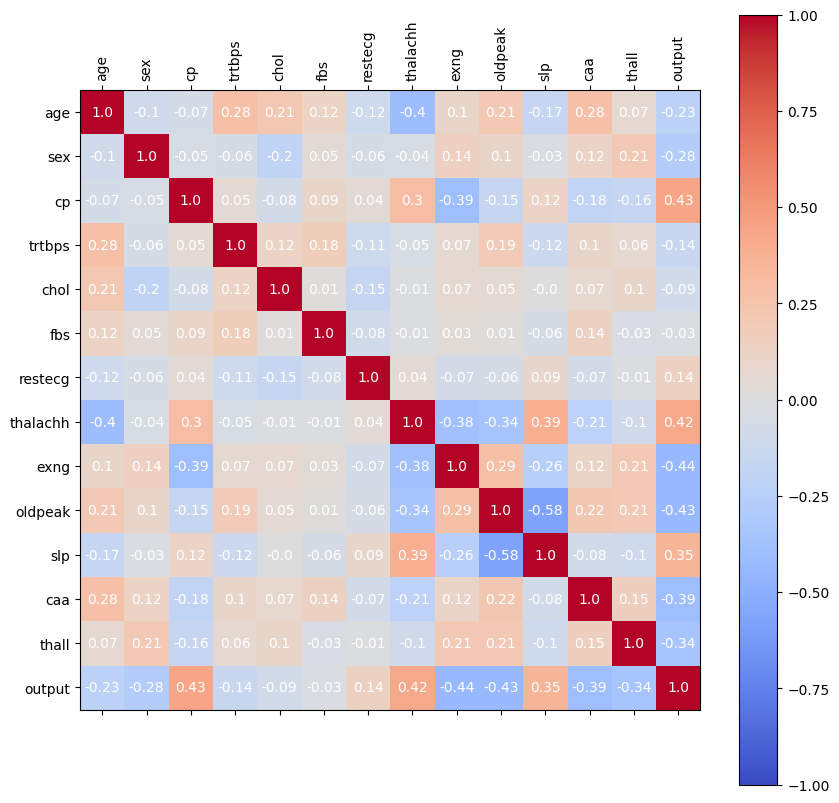

In [9]:
# Plot the correlation matrix (corr) using seaborn
fig, ax = plt.subplots(figsize=(10, 10))
cax = ax.matshow(corr,cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
ticks = np.arange(0,len(df.columns),1)
ax.set_xticks(ticks)
ax.set_xticklabels(df.columns)
plt.xticks(rotation = 90)
ax.set_yticklabels(df.columns)
ax.set_yticks(ticks)
#---print the correlation factor---
for i in range(df.shape[1]):
    for j in range(df.shape[1]):
        text = ax.text(j, i, round(corr.iloc[i, j], 2),
        ha="center", va="center", color="w")
plt.show()

## Feature Selection and Target Variable

Select the most relevant features for our model and define the target variable.
<br>Note. For this task we will choose 4 features.

In [10]:
# Split the dataset into X and y
# X contains the selected columns
# y contains the target column
# ---------------------
# CODE HERE
# ---------------------
selected_features = ['cp', 'thalachh', 'exng', 'oldpeak'] 
X = df[selected_features]
y = df['output']

## Data Preprocessing: Feature Scaling

Standardize the features to have mean=0 and variance=1, which is important for many ML algorithms.
<br>Note. If you use this Data Preprocessing step, you should also apply it to the prediction step as well.

In [11]:
# Data Preprocessing
# ---------------------
# CODE HERE
# ---------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Save the preprocessing model

In [14]:
import pickle
# Save the "StandardScaler" model to a file using pickle
# ---------------------
# CODE HERE
# ---------------------
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

## Model Evaluation Using Cross-Validation

We'll evaluate multiple machine learning models using 10-fold cross-validation to find the best performer.
<br>Note. The train/test split is not necessary when using cross-validation because the data is split into training and testing sets multiple times.

In [13]:
# Import the cross_val_score from sklearn
from sklearn.model_selection import cross_val_score

### Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

folds = 10 

logRe = LogisticRegression()
logRe_score = cross_val_score(logRe, X_scaled, y, cv=folds, scoring='accuracy').mean()
print('LogisticRegression',logRe_score)

LogisticRegression 0.795483870967742


### K-Nearest Neighbors

Test different values of k to find the optimal number of neighbors.

In [16]:
from sklearn.neighbors import KNeighborsClassifier

cv_scores = []
ks = list(range(1,int(len(X) * ((folds - 1)/folds)), 2))
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn, X_scaled, y, cv=folds, scoring='accuracy').mean()
    cv_scores.append(score)
knn_score = max(cv_scores)
optimal_k = ks[cv_scores.index(knn_score)]
print('kNN',(optimal_k,knn_score))

kNN (89, np.float64(0.7953763440860214))


### Decision Tree

Test different tree depths to find the optimal complexity.

In [17]:
from sklearn.tree import DecisionTreeClassifier

depth = []
for i in range(3,20):
    clf = DecisionTreeClassifier(max_depth=i, random_state=42)
    scores = cross_val_score(clf, X_scaled, y, cv=folds, n_jobs=4)
    depth.append([i,scores.mean()])
depth = np.array(depth)
d = depth[np.argmax(depth[:,1], axis=0),0]
s = depth[np.argmax(depth[:,1], axis=0),1]
print('Tree',(int(d),s))

Tree (4, np.float64(0.7623655913978495))


### Support Vector Machines

Test SVM with different kernels: linear and radial basis function (RBF).

In [18]:
from sklearn import svm

# Linear kernel
linear_svm = svm.SVC(kernel='linear')
linear_svm_score = cross_val_score(linear_svm, X_scaled, y, cv=folds, scoring='accuracy').mean()
print('SVM-L',linear_svm_score)

# RBF kernel
rbf_svm = svm.SVC(kernel='rbf')
rbf_svm_score = cross_val_score(rbf_svm, X_scaled, y, cv=folds, scoring='accuracy').mean()
print('SVM-rbf',rbf_svm_score)

SVM-L 0.8018279569892475
SVM-rbf 0.7789247311827957


### Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf_score = cross_val_score(rf, X_scaled, y, cv=folds, scoring='accuracy').mean()
print('Random Forest',rf_score)

Random Forest 0.7427956989247313


# Conclusion

In [20]:
print('Best model is', "SVM with L kernel score is "+str(linear_svm_score))

Best model is SVM with L kernel score is 0.8018279569892475


## Train and Save the Best Model

Based on the evaluation, we'll train the Logistic Regression model on the full dataset and save it for future use.

In [ ]:
import pickle

# Train the final model using the best algorithm
# In this case, we will use the whole dataset to train the model
# and save the model to disk
# ---------------------
# CODE HERE
# ---------------------
final_model = LogisticRegression()
final_model.fit(X_scaled, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Save the model to a file using the pickle library.

In [22]:
# Save the model to disk
# ---------------------
# CODE HERE
# ---------------------
with open('best_model.pkl', 'wb') as file:
    pickle.dump(final_model, file)